In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [11]:
from google.colab import files
files.upload()

Saving test.csv to test (1).csv
Saving train.csv to train (1).csv


{'test (1).csv': b'PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked\r\n1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.25,,S\r\n2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38,1,0,PC 17599,71.2833,C85,C\r\n3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.925,,S\r\n4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1,C123,S\r\n5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.05,,S\r\n6,0,3,"Moran, Mr. James",male,,0,0,330877,8.4583,,Q\r\n7,0,1,"McCarthy, Mr. Timothy J",male,54,0,0,17463,51.8625,E46,S\r\n8,0,3,"Palsson, Master. Gosta Leonard",male,2,3,1,349909,21.075,,S\r\n9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27,0,2,347742,11.1333,,S\r\n10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14,1,0,237736,30.0708,,C\r\n11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4,1,1,PP 9549,16.7,G6,S\r\n12,1,1,"Bonnell, Miss. Elizabeth",female,58,0,0,113783,26.55,C103,S

In [12]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

Percentage of people traveling alone who survived: 30.353817504655495
Percentage of people NOT alone who survived: 50.56497175141242


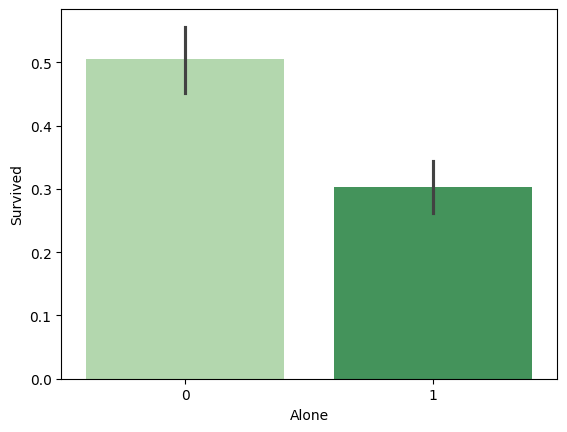

In [13]:
# Create a new column "Alone"
train["Alone"] = (train["SibSp"] == 0) & (train["Parch"] == 0)

# Convert True/False to 1/0
train["Alone"] = train["Alone"].map({True: 1, False: 0})

# Plot
sns.barplot(x="Alone", y="Survived", data=train, palette="Greens")

# Percentage calculation
print("Percentage of people traveling alone who survived:",
      train["Survived"][train["Alone"] == 1].value_counts(normalize=True)[1] * 100)

print("Percentage of people NOT alone who survived:",
      train["Survived"][train["Alone"] == 0].value_counts(normalize=True)[1] * 100)

Percentage of females who survived: 74.20382165605095
Percentage of males who survived: 18.890814558058924


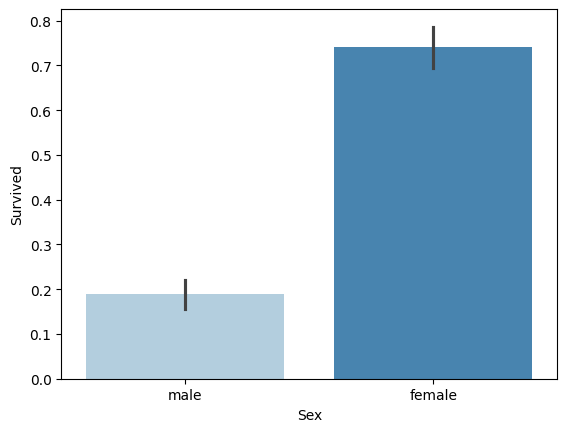

In [14]:
sns.barplot(x="Sex", y="Survived", data=train, palette = "Blues")

#print percentages of females vs. males that survive
print("Percentage of females who survived:", train["Survived"][train["Sex"] == 'female'].value_counts(normalize = True)[1]*100)

print("Percentage of males who survived:", train["Survived"][train["Sex"] == 'male'].value_counts(normalize = True)[1]*100)

Survival rate in Pclass 1: 62.96296296296296
Survival rate in Pclass 2: 47.28260869565217
Survival rate in Pclass 3: 24.236252545824847


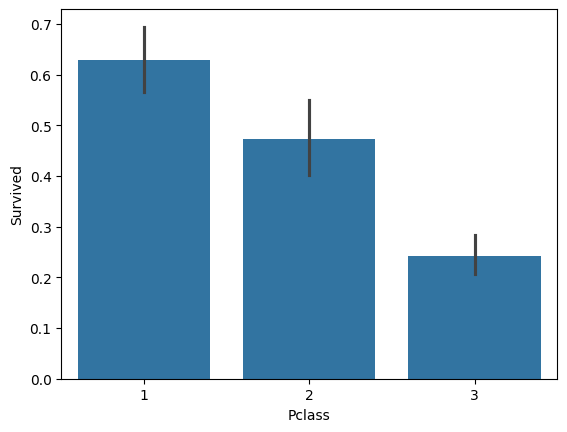

In [15]:
sns.barplot(x="Pclass", y="Survived", data=train)

print("Survival rate in Pclass 1:",
      train[train["Pclass"] == 1]["Survived"].mean() * 100)

print("Survival rate in Pclass 2:",
      train[train["Pclass"] == 2]["Survived"].mean() * 100)

print("Survival rate in Pclass 3:",
      train[train["Pclass"] == 3]["Survived"].mean() * 100)

Passengers in higher class (Pclass 1) have a higher survival rate compared to lower classes. This supports the hypothesis that socioeconomic status affected survival.

Survival rate (SibSp=0): 34.53947368421053
Survival rate (SibSp>0): 46.64310954063604


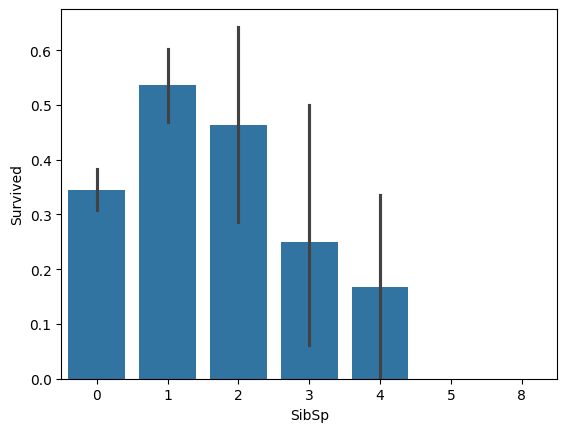

In [16]:
sns.barplot(x="SibSp", y="Survived", data=train)

print("Survival rate (SibSp=0):",
      train[train["SibSp"] == 0]["Survived"].mean() * 100)

print("Survival rate (SibSp>0):",
      train[train["SibSp"] > 0]["Survived"].mean() * 100)

Passengers with no siblings/spouse (SibSp = 0) show a different survival pattern compared to those traveling with family. This indicates family size may influence survival chances.

Survival rate (Parch=0): 34.365781710914455
Survival rate (Parch>0): 51.173708920187785


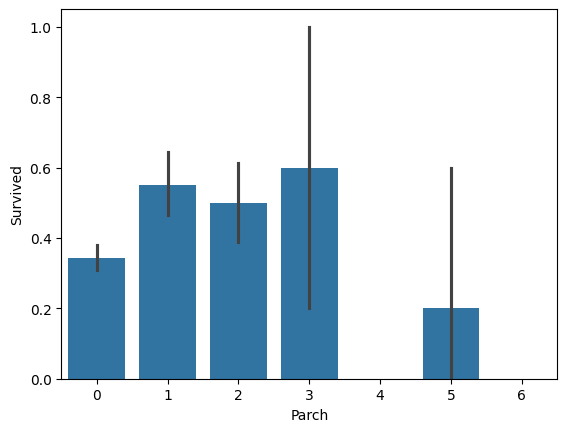

In [17]:
sns.barplot(x="Parch", y="Survived", data=train)

print("Survival rate (Parch=0):",
      train[train["Parch"] == 0]["Survived"].mean() * 100)

print("Survival rate (Parch>0):",
      train[train["Parch"] > 0]["Survived"].mean() * 100)

Passengers traveling without parents/children (Parch = 0) show different survival rates compared to those with family. This suggests family relationships may impact survival.

Survival rate of children: 50.35971223021583
Survival rate of adults: 36.17021276595745


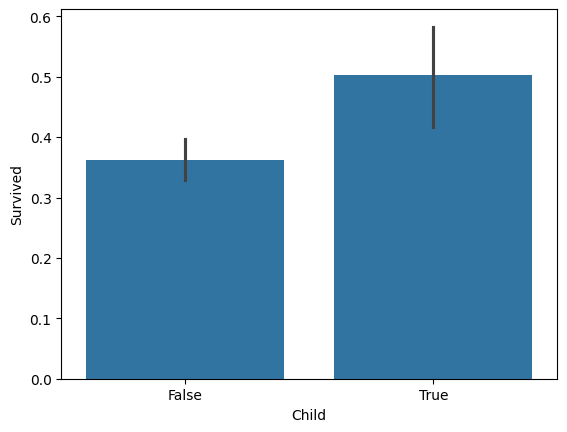

In [18]:
# Create child column
train["Child"] = train["Age"] <= 18

sns.barplot(x="Child", y="Survived", data=train)

print("Survival rate of children:",
      train[train["Child"] == True]["Survived"].mean() * 100)

print("Survival rate of adults:",
      train[train["Child"] == False]["Survived"].mean() * 100)

Passengers aged 18 or below are considered children. The survival rate of children is higher than adults, supporting the hypothesis that younger passengers had better chances of survival.